# TD3
이 튜토리얼은 **TD3 (Twin Delayed DDPG)** 알고리즘을 구현하는 방법을 안내한다.

**TD3 (Twin Delayed Deep Deterministic Policy Gradient)**는 DDPG의 성능을 개선하기 위해 제안된 알고리즘이다. DDPG가 Q값을 과대평가(Overestimation)하는 문제를 해결하기 위해 다음 3가지 핵심 기법을 도입했다.

1. **Clipped Double Q-Learning**: 두 개의 Critic(Q함수)을 사용하여 더 작은 Q값을 타겟으로 사용한다.
2. **Target Policy Smoothing**: 타겟 행동에 노이즈를 더해 Q함수가 좁은 영역에서 급격하게 변하는 것을 방지한다.
3. **Delayed Policy Updates**: Critic보다 Actor(정책)를 덜 자주 업데이트하여 학습을 안정화한다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 기준으로 작성되었으며, `LunarLanderContinuous-v2` 환경을 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Actor & Critic 네트워크 생성 (Create Actor & Critic Networks)

TD3는 DDPG와 유사한 구조를 가지지만, Critic이 2개 필요하다는 점이 다르다.

In [4]:
class Actor(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim, max_action):
        """
        Actor 네트워크: 상태를 입력받아 행동을 출력
        """
        super().__init__()
        self.max_action = float(max_action)
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, action_dim),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x) * self.max_action

class Critic(nn.Module):
    def __init__(self, obs_size, hidden_size, action_dim):
        """
        Critic 네트워크: 상태와 행동을 입력받아 Q-Value를 예측
        TD3는 이러한 Critic을 2개 사용한다.
        """
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_size + action_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, state, action):
        x = torch.cat([state, action], dim=1)
        return self.net(x)

### 5. 경험 리플레이 버퍼 (Replay Buffer)

데이터 저장을 위한 버퍼다.

In [5]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (TD3 알고리즘 구현)

TD3의 핵심 로직(Twin Critic, Target Smoothing, Delayed Update)을 모두 포함하는 클래스다.

In [6]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=256, actor_lr=1e-4, critic_lr=1e-3,
                 capacity=100000, gamma=0.99, batch_size=128, tau=0.005,
                 policy_noise=0.2, noise_clip=0.5, policy_delay=2):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.policy_noise = policy_noise   # 타겟 행동에 더할 노이즈 표준편차
        self.noise_clip = noise_clip       # 노이즈 클리핑 범위
        self.policy_delay = policy_delay   # Actor 업데이트 지연 주기
        self.total_it = 0                  # 총 업데이트 횟수 카운트

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dim = self.env.action_space.shape[0]
        max_action = self.env.action_space.high[0]

        # 네트워크 초기화 (Actor 1개, Critic 2개)
        self.actor = Actor(obs_size, hidden_size, action_dim, max_action).to(device)
        self.actor_target = copy.deepcopy(self.actor).to(device)

        self.critic1 = Critic(obs_size, hidden_size, action_dim).to(device)
        self.critic1_target = copy.deepcopy(self.critic1).to(device)

        self.critic2 = Critic(obs_size, hidden_size, action_dim).to(device)
        self.critic2_target = copy.deepcopy(self.critic2).to(device)

        # 최적화기
        self.actor_optimizer = optim.AdamW(self.actor.parameters(), lr=actor_lr)
        self.critic_optimizer = optim.AdamW(
            list(self.critic1.parameters()) + list(self.critic2.parameters()),
            lr=critic_lr
        )

        self.buffer = ReplayBuffer(capacity)
        self.max_action = max_action

    def get_action(self, state, noise_scale=0.1):
        """탐험을 위한 노이즈가 추가된 행동 선택"""
        state_t = torch.tensor(np.array([state]), dtype=torch.float32, device=device)

        self.actor.eval()
        with torch.no_grad():
            action = self.actor(state_t).cpu().numpy()[0]
        self.actor.train()

        noise = np.random.normal(0, noise_scale * self.max_action, size=action.shape)
        action = np.clip(action + noise, -self.max_action, self.max_action)
        return action

    def soft_update(self, net, target_net):
        for param, target_param in zip(net.parameters(), target_net.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0, 0.0

        self.total_it += 1
        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.float32, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)

        # ----------------------------
        # 1. Critic 업데이트
        # ----------------------------
        with torch.no_grad():
            # Target Policy Smoothing: 타겟 행동에 노이즈 추가
            noise = (torch.randn_like(actions) * self.policy_noise).clamp(-self.noise_clip, self.noise_clip)
            next_actions = (self.actor_target(next_states) + noise).clamp(-self.max_action, self.max_action)

            # Clipped Double Q-Learning: 두 타겟 Q값 중 작은 값 선택
            target_q1 = self.critic1_target(next_states, next_actions)
            target_q2 = self.critic2_target(next_states, next_actions)
            target_q = torch.min(target_q1, target_q2)
            y_target = rewards + (1 - dones) * self.gamma * target_q

        # 현재 Q값 예측
        current_q1 = self.critic1(states, actions)
        current_q2 = self.critic2(states, actions)

        # Critic 손실 (두 Critic의 손실 합)
        critic_loss = F.mse_loss(current_q1, y_target) + F.mse_loss(current_q2, y_target)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        actor_loss_val = 0.0

        # ----------------------------
        # 2. Actor 업데이트 (Delayed Update)
        # ----------------------------
        if self.total_it % self.policy_delay == 0:
            # Actor 손실: Q1 값을 최대화
            predicted_actions = self.actor(states)
            actor_loss = -self.critic1(states, predicted_actions).mean()

            self.actor_optimizer.zero_grad()
            actor_loss.backward()
            self.actor_optimizer.step()

            # 타겟 네트워크 소프트 업데이트
            self.soft_update(self.actor, self.actor_target)
            self.soft_update(self.critic1, self.critic1_target)
            self.soft_update(self.critic2, self.critic2_target)

            actor_loss_val = actor_loss.item()

        return critic_loss.item(), actor_loss_val

    def run_training(self, max_episodes=600, max_steps=1000):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            # 탐험 노이즈
            noise_scale = max(0.1, 0.1 - (episode / 500))

            for step in range(max_steps):
                action = self.get_action(state, noise_scale)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            total_rewards.append(episode_reward)

            if episode % 10 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Noise: {noise_scale:.3f}")

        return total_rewards

    def save_video(self, filename="td3_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            action = self.get_action(state, noise_scale=0.0)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

TD3 에이전트를 생성하고 학습을 시작한다. DDPG보다 학습이 안정적이고 성능이 좋은 편이다.

In [8]:
# TD3 모델 생성
agent = PytorchWrapper(
    'LunarLanderContinuous-v3',
    hidden_size=256,
    actor_lr=3e-4,
    critic_lr=3e-4,
    batch_size=256,
    policy_noise=0.2,
    noise_clip=0.5,
    policy_delay=2
)

# 학습 시작
print("TD3 (Twin Delayed DDPG) 학습을 시작한다...")
history = agent.run_training(max_episodes=500)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


TD3 (Twin Delayed DDPG) 학습을 시작한다...
Episode 0, Reward: -288.94, Noise: 0.100
Episode 10, Reward: -306.29, Noise: 0.100
Episode 20, Reward: -315.79, Noise: 0.100
Episode 30, Reward: -131.79, Noise: 0.100
Episode 40, Reward: -128.45, Noise: 0.100
Episode 50, Reward: -268.64, Noise: 0.100
Episode 60, Reward: -158.95, Noise: 0.100
Episode 70, Reward: -191.94, Noise: 0.100
Episode 80, Reward: -290.27, Noise: 0.100
Episode 90, Reward: -212.03, Noise: 0.100
Episode 100, Reward: 47.06, Noise: 0.100
Episode 110, Reward: -210.71, Noise: 0.100
Episode 120, Reward: 27.18, Noise: 0.100
Episode 130, Reward: -117.70, Noise: 0.100
Episode 140, Reward: -97.58, Noise: 0.100
Episode 150, Reward: -36.49, Noise: 0.100
Episode 160, Reward: -316.17, Noise: 0.100
Episode 170, Reward: -227.21, Noise: 0.100
Episode 180, Reward: -1.51, Noise: 0.100
Episode 190, Reward: -269.88, Noise: 0.100
Episode 200, Reward: -360.09, Noise: 0.100
Episode 210, Reward: -93.25, Noise: 0.100
Episode 220, Reward: -131.42, Noise: 0

### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

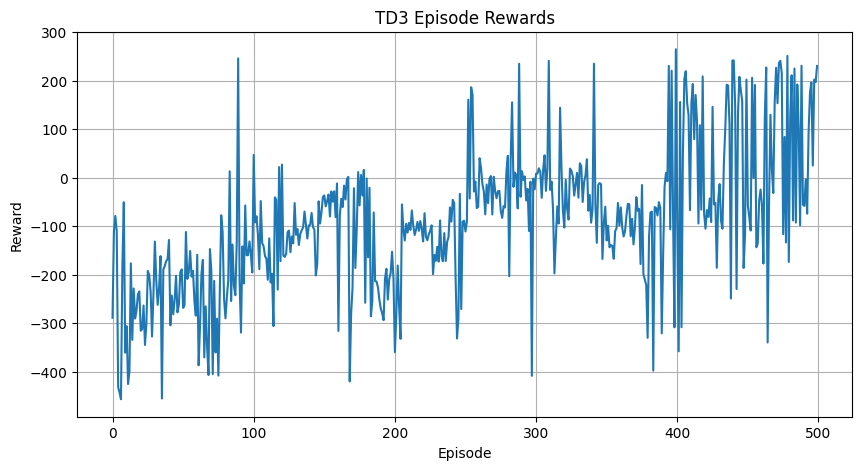

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("TD3 Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("td3")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")